In [50]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
from sklearn.datasets import load_iris

In [52]:
# df = pd.read_csv('/Users/ankushkumar/AI-Ml/Machine Learning/class-01/Titanic-Dataset.csv')
# df.head()

In [53]:
df = pd.read_csv('/Users/ankushkumar/AI-Ml/Machine Learning/class-01/mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


In [55]:
df = df.drop(columns=['origin', 'name'])
df['horsepower'] = df['horsepower'].fillna(
    df['horsepower'].median()
)
print(df.shape, "|", df.isna().sum().sum(), "missing values")

(398, 7) | 0 missing values


In [56]:
x = df.drop(columns=['mpg'])
y = df['mpg']
print(x.shape, y.shape)

(398, 6) (398,)


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(x_train.shape, x_test.shape)

(318, 6) (80, 6)


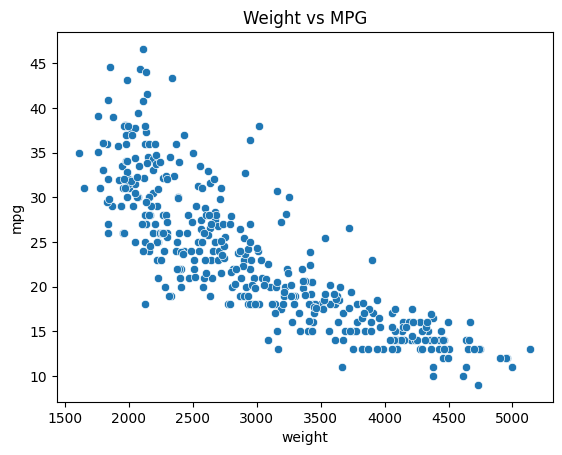

In [59]:
sns.scatterplot(x='weight', y='mpg', data=df)
plt.title('Weight vs MPG')
plt.show()


In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
model = LinearRegression()
model.fit(x_train[['weight']], y_train)
print("coef     ", model.coef_)
print("intercept", model.intercept_)


coef      [-0.00780524]
intercept 46.78206336645047


In [62]:
print(model.score(x_test[['weight']], y_test))

0.722971057303075


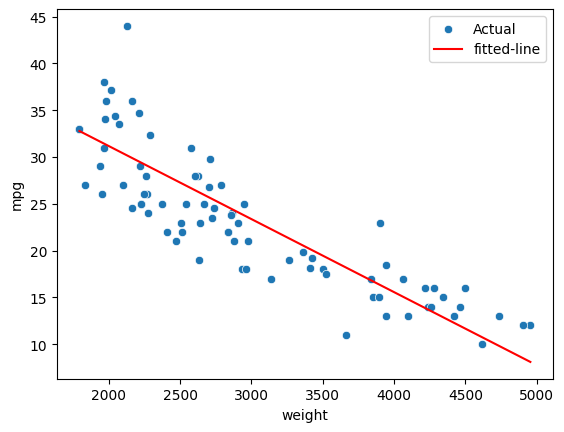

In [63]:
sns.scatterplot(x=x_test['weight'], y=y_test, label='Actual')
sns.lineplot(x=x_test['weight'], y=model.predict(x_test[['weight']]), color='red', label='fitted-line')
plt.show()

In [64]:
model_all = LinearRegression()
model_all.fit(x_train, y_train)
print(model_all.score(x_test, y_test))

0.8244245330943358


In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [66]:
x_pred = model_all.predict(x_test)
print("MAE", mean_absolute_error(y_test, x_pred))
print("MSE", mean_squared_error(y_test, x_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, x_pred)))
print("R2", r2_score(y_test, x_pred))


MAE 2.466780800452034
MSE 9.440068465263384
RMSE 3.0724694408998414
R2 0.8244245330943358


In [67]:
x_tr2, x_te2, y_tr2, y_te2 = train_test_split(x, y, test_size=0.2, random_state=7)
print(LinearRegression().fit(x_tr2, y_tr2).score(x_te2, y_te2))

0.7197593303392955


In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_scaled.shape, x_test_scaled.shape)


(318, 6) (80, 6)


In [69]:
model_scaled = LinearRegression()
model_scaled.fit(x_scaled, y_train)
print("without scaling", model_all.score(x_test, y_test))
print("with scaling   ", model_scaled.score(x_test_scaled, y_test))

without scaling 0.8244245330943358
with scaling    0.8244245330943358


In [70]:
pd.DataFrame({
    'feature': x_train.columns,
    'coef without scaling': model_all.coef_.round(3),
    'coef with scaling': model_scaled.coef_.round(3)
})



,feature,coef without scaling,coef with scaling
0,cylinders,0.069,0.116
1,displacement,0.002,0.165
2,horsepower,0.003,0.107
3,weight,-0.007,-5.912
4,acceleration,0.081,0.222
5,model_year,0.801,2.883


In [71]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)
acc_knn_raw = knn.score(x_test, y_test)
print("KNN without scaling", acc_knn_raw)


KNN without scaling 0.7659996807953288


In [76]:
from sklearn.neighbors import KNeighborsRegressor
knn_scaled = KNeighborsRegressor()
# Train using TRAINING data
knn_scaled.fit(x_test_scaled, y_train)
# Test using TEST data
acc_knn_scaled = knn_scaled.score(x_test_scaled, y_test)
print("KNN with scaling:", acc_knn_scaled)

ValueError: Found input variables with inconsistent numbers of samples: [80, 318]

In [74]:
pd.DataFrame({
    'model': ['Linear Regression', 'KNN regressor without scaling', 'KNN with scaling'],
    'R2': [round(model_all.score(x_test, y_test), 3), round(acc_knn_raw, 3), round(r2_knn_scaled, 3)]
    
})

NameError: name 'r2_knn_scaled' is not defined